In [2]:
import torch
print(torch.cuda.get_arch_list())
print(torch.cuda.is_available())

['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
True


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("=" * 50)
print("🔧 PyTorch 环境测试")
print("=" * 50)

# 1. 检查版本
print(f"\n✅ PyTorch 版本：{torch.__version__}")
print(f"✅ CUDA 可用：{torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"✅ GPU 名称：{torch.cuda.get_device_name(0)}")
    print(f"✅ CUDA 版本：{torch.version.cuda}")
    device = torch.device("cuda")
else:
    print("⚠️  未检测到 GPU，将使用 CPU 训练")
    device = torch.device("cpu")

# 2. 简单测试：矩阵运算
print("\n" + "=" * 50)
print("📊 测试 1：基础张量运算")
print("=" * 50)
x = torch.randn(3, 3, device=device)
y = torch.randn(3, 3, device=device)
z = torch.matmul(x, y)
print(f"张量设备：{z.device}")
print(f"计算结果形状：{z.shape}")
print("✅ 基础运算通过！")

# 3. 完整训练测试：简单神经网络
print("\n" + "=" * 50)
print("🧠 测试 2：完整训练流程")
print("=" * 50)

# 定义简单模型
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )
    
    def forward(self, x):
        return self.net(x)

model = SimpleNet().to(device)

# 创建假数据（二分类任务）
X_train = torch.randn(1000, 10, device=device)
y_train = torch.randint(0, 2, (1000,), device=device)
dataset = TensorDataset(X_train, y_train)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 训练 3 个 epoch
print("\n开始训练...")
for epoch in range(3):
    total_loss = 0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    print(f"  Epoch {epoch+1}/3, Loss: {avg_loss:.4f}")

print("\n✅ 完整训练流程通过！")

# 4. 测试推理
print("\n" + "=" * 50)
print("🔍 测试 3：模型推理")
print("=" * 50)
model.eval()
with torch.no_grad():
    test_input = torch.randn(5, 10, device=device)
    predictions = model(test_input)
    print(f"输入形状：{test_input.shape}")
    print(f"输出形状：{predictions.shape}")
    print(f"预测结果：{predictions.argmax(dim=1)}")

print("\n✅ 推理测试通过！")

# 5. 最终总结
print("\n" + "=" * 50)
print("🎉 所有测试通过！环境配置成功！")
print("=" * 50)

🔧 PyTorch 环境测试

✅ PyTorch 版本：2.12.0.dev20260318+cu128
✅ CUDA 可用：True
✅ GPU 名称：NVIDIA GeForce RTX 5070 Laptop GPU
✅ CUDA 版本：12.8

📊 测试 1：基础张量运算
张量设备：cuda:0
计算结果形状：torch.Size([3, 3])
✅ 基础运算通过！

🧠 测试 2：完整训练流程

开始训练...
  Epoch 1/3, Loss: 0.6980
  Epoch 2/3, Loss: 0.6855
  Epoch 3/3, Loss: 0.6826

✅ 完整训练流程通过！

🔍 测试 3：模型推理
输入形状：torch.Size([5, 10])
输出形状：torch.Size([5, 2])
预测结果：tensor([0, 1, 1, 1, 0], device='cuda:0')

✅ 推理测试通过！

🎉 所有测试通过！环境配置成功！


🎨 CLIP 零样本图像分类

✅ 使用设备：cuda
🔄 正在加载 CLIP 模型...
✅ 模型加载完成！

✅ 图片加载成功：C:\Users\napuc\OneDrive\Desktop\1.jpg
   原始尺寸：(2048, 2731)

🏷️  请输入分类标签（用逗号分隔）
   示例：cat, dog, bird, car, tree
⚠️  使用默认标签：['cat', 'dog', 'bird', 'car', 'tree', 'person', 'building', 'food']

✅ 共 8 个分类标签：['cat', 'dog', 'bird', 'car', 'tree', 'person', 'building', 'food']

🔍 开始推理...

📊 分类结果：
------------------------------------------------------------
排名    标签                  概率          相似度         
------------------------------------------------------------
🏆1    tree                 99.61%     0.2737
  2    bird                  0.17%     0.2098
  3    building              0.09%     0.2032
  4    person                0.08%     0.2028
  5    dog                   0.01%     0.1852
  6    food                  0.01%     0.1843
  7    cat                   0.01%     0.1790
  8    car                   0.01%     0.1788
------------------------------------------------------------

🎯 最可能的分类：【tree】(置信度：99.61%)

📈 正在生成可视化图表.

C:\Users\napuc\AppData\Local\Temp\ipykernel_46428\1203799993.py:132: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\napuc\AppData\Local\Temp\ipykernel_46428\1203799993.py:132: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\napuc\AppData\Local\Temp\ipykernel_46428\1203799993.py:132: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\napuc\AppData\Local\Temp\ipykernel_46428\1203799993.py:132: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\napuc\AppData\Local\Temp\ipykernel_46428\1203799993.py:132: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\napuc\AppData\Local\Temp\ipykernel_46428\1203799993.py:132: UserWarning: Glyph 39044 (\N{CJK UNIFIED

✅ 结果已保存为：clip_result.png


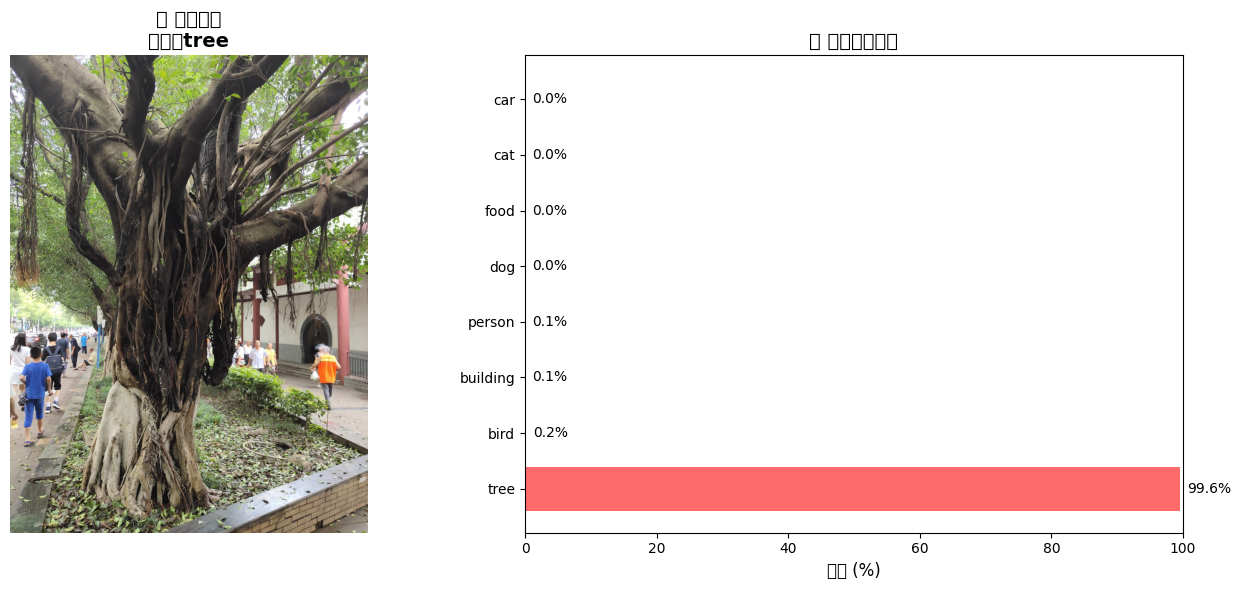


✨ 推理完成！


In [6]:
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt
import os

print("=" * 60)
print("🎨 CLIP 零样本图像分类")
print("=" * 60)

# ==================== 配置 ====================
# 检查设备
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n✅ 使用设备：{device}")

# 加载 CLIP 模型（可选："ViT-B/32", "ViT-B/16", "ViT-L/14"）
print("🔄 正在加载 CLIP 模型...")
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()
print("✅ 模型加载完成！\n")

# ==================== 输入图片 ====================
# 方式 1：直接指定图片路径
image_path = input("📷 请输入图片路径（直接回车使用测试图片）：").strip()

if not image_path:
    # 如果没有输入，创建一张测试图片
    print("⚠️  未提供图片，使用测试图片...")
    test_image = Image.new('RGB', (224, 224), color='blue')
    image_path = "test_image.png"
    test_image.save(image_path)
else:
    # 检查文件是否存在
    if not os.path.exists(image_path):
        print(f"❌ 错误：文件 '{image_path}' 不存在！")
        exit(1)

# 加载并预处理图片
try:
    image = Image.open(image_path).convert("RGB")
    image_input = preprocess(image).unsqueeze(0).to(device)
    print(f"✅ 图片加载成功：{image_path}")
    print(f"   原始尺寸：{image.size}")
except Exception as e:
    print(f"❌ 图片加载失败：{e}")
    exit(1)

# ==================== 输入标签 ====================
print("\n🏷️  请输入分类标签（用逗号分隔）")
print("   示例：cat, dog, bird, car, tree")
label_input = input("   标签：").strip()

if not label_input:
    # 默认标签
    labels = ["cat", "dog", "bird", "car", "tree", "person", "building", "food"]
    print(f"⚠️  使用默认标签：{labels}")
else:
    labels = [l.strip() for l in label_input.split(",")]

print(f"\n✅ 共 {len(labels)} 个分类标签：{labels}")

# ==================== CLIP 推理 ====================
print("\n" + "=" * 60)
print("🔍 开始推理...")
print("=" * 60)

with torch.no_grad():
    # 1. 编码图片
    image_features = model.encode_image(image_input)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    
    # 2. 编码文本标签
    text_tokens = clip.tokenize(labels).to(device)
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    
    # 3. 计算相似度
    similarity = (image_features @ text_features.T).squeeze(0)
    probabilities = torch.softmax(similarity * 100, dim=0)  # temperature=100
    
    # 4. 排序结果
    results = []
    for i, (label, prob) in enumerate(zip(labels, probabilities)):
        results.append({
            'label': label,
            'probability': prob.item(),
            'similarity': similarity[i].item()
        })
    
    # 按概率降序排序
    results.sort(key=lambda x: x['probability'], reverse=True)

# ==================== 输出结果 ====================
print("\n📊 分类结果：")
print("-" * 60)
print(f"{'排名':<6}{'标签':<20}{'概率':<12}{'相似度':<12}")
print("-" * 60)

for i, result in enumerate(results, 1):
    marker = "🏆" if i == 1 else "  "
    print(f"{marker}{i:<5}{result['label']:<20}{result['probability']*100:>6.2f}%   {result['similarity']:>8.4f}")

print("-" * 60)
print(f"\n🎯 最可能的分类：【{results[0]['label']}】(置信度：{results[0]['probability']*100:.2f}%)")

# ==================== 可视化 ====================
print("\n📈 正在生成可视化图表...")

# 创建图表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 左图：显示原图
ax1.imshow(image)
ax1.set_title(f"📷 输入图片\n预测：{results[0]['label']}", fontsize=14, fontweight='bold')
ax1.axis('off')

# 右图：概率柱状图
labels_display = [r['label'] for r in results]
probs_display = [r['probability']*100 for r in results]
colors = ['#FF6B6B' if i == 0 else '#4ECDC4' for i in range(len(results))]

bars = ax2.barh(labels_display, probs_display, color=colors)
ax2.set_xlabel('概率 (%)', fontsize=12)
ax2.set_title('📊 分类概率分布', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 100)

# 在柱子上显示数值
for i, (bar, prob) in enumerate(zip(bars, probs_display)):
    ax2.text(prob + 1, bar.get_y() + bar.get_height()/2, 
             f'{prob:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig("clip_result.png", dpi=150, bbox_inches='tight')
print("✅ 结果已保存为：clip_result.png")
plt.show()

print("\n" + "=" * 60)
print("✨ 推理完成！")
print("=" * 60)